In [2]:
#Import basic libraries
import pandas as pd
import numpy as np
import zipfile
import os

In [3]:
#check where your notebook is
os.getcwd()

'C:\\Users\\prash\\Documents\\DiabetesCapstone-master\\Notebooks'

In [4]:
file_path = "../Data/archive/diabetes.csv"

df = pd.read_csv(file_path)

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [6]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [7]:
#Identify bad columns
cols_with_zero_issue = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

for col in cols_with_zero_issue:
    print(col, (df[col] == 0).sum())

Glucose 5
BloodPressure 35
SkinThickness 227
Insulin 374
BMI 11


In [8]:
#Replace 0 with NaN
df[cols_with_zero_issue] = df[cols_with_zero_issue].replace(0, np.nan)

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   763 non-null    float64
 2   BloodPressure             733 non-null    float64
 3   SkinThickness             541 non-null    float64
 4   Insulin                   394 non-null    float64
 5   BMI                       757 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(6), int64(3)
memory usage: 54.1 KB


In [10]:
#fill missing values with median
for col in cols_with_zero_issue: #python goes thorugh each column in cols_with_zero_issue one by one
    df[col] = df[col].fillna(df[col].median())
    
    # df[col] will be one entire column at a time
    # df[col].median() means find the median of this column
    # fillna means replace nan
    # df[col] = means save the changes back into the dataframe.

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    float64
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    float64
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(6), int64(3)
memory usage: 54.1 KB


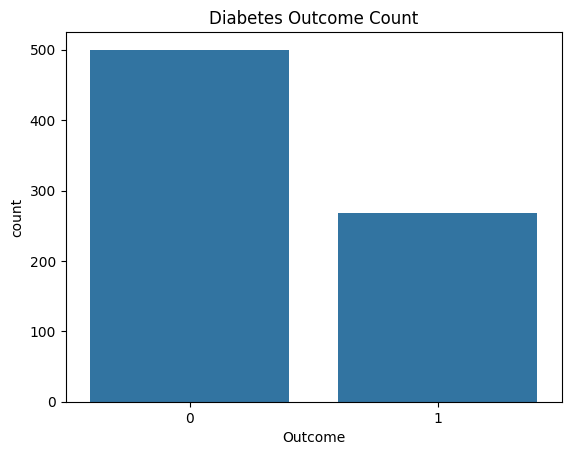

In [12]:
# how many people have diabetes (1)
# how many do not (0)

import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Outcome', data=df)
plt.title('Diabetes Outcome Count')
plt.show()

## Exploratory Data Analysis (EDA)

### Feature Relationship Analysis 

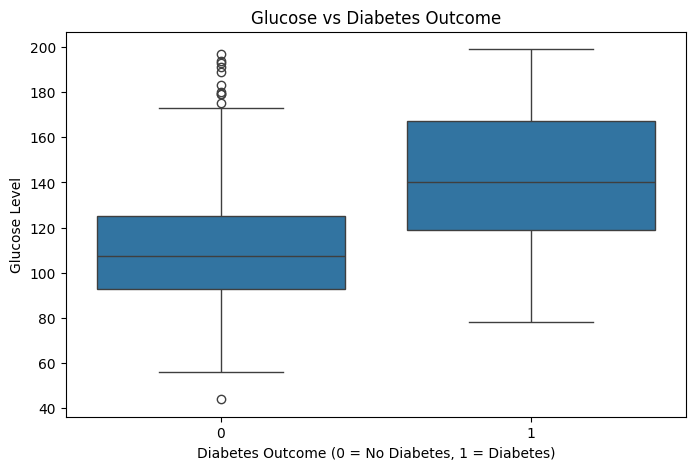

In [14]:
#Which variables differ between diabetic vs non-diabetic patients.
plt.figure(figsize=(8,5))

sns.boxplot(x='Outcome', y='Glucose', data=df)

plt.title('Glucose vs Diabetes Outcome')
plt.xlabel('Diabetes Outcome (0 = No Diabetes, 1 = Diabetes)')
plt.ylabel('Glucose Level')

plt.show()

The boxplot shows that patients with diabetes (Outcome = 1) generally have higher glucose levels compared to non-diabetic patients (Outcome = 0).
The median glucose level is noticeably higher for diabetic patients, suggesting that glucose is likely an important predictor variable for diabetes classification.
There are also several outliers in both groups, indicating variability in glucose measurements across patients.

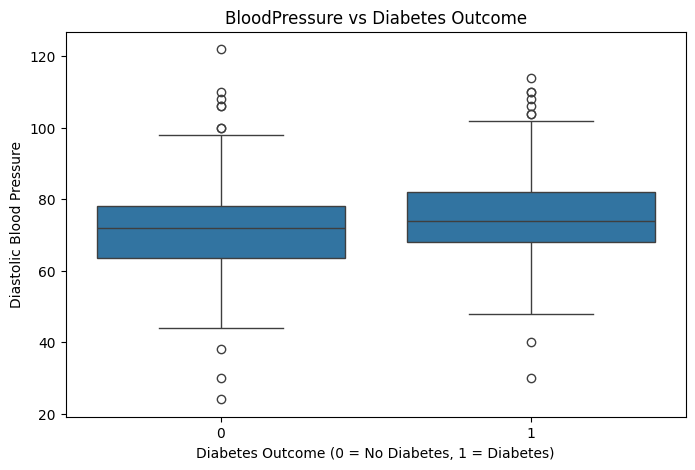

In [17]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Outcome', y='BloodPressure', data=df)

plt.title('BloodPressure vs Diabetes Outcome')
plt.xlabel('Diabetes Outcome (0 = No Diabetes, 1 = Diabetes)')
plt.ylabel('Diastolic Blood Pressure')

plt.show()


The boxplot shows that diabetic patients tend to have slightly higher blood pressure values compared to non-diabetic patients. However, there is substantial overlap between the two groups.
This suggests that BloodPressure may have a weaker relationship with diabetes outcome compared to variables such as Glucose.
Several outliers are also present in both groups, indicating variability and potential data quality issues.

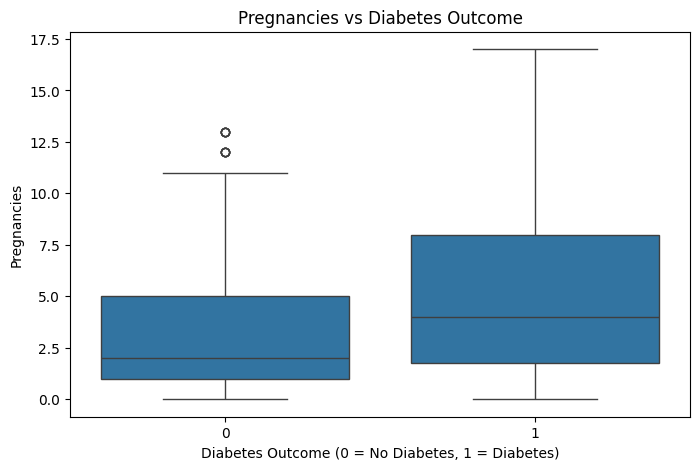

In [18]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Outcome', y='Pregnancies', data=df)

plt.title('Pregnancies vs Diabetes Outcome')
plt.xlabel('Diabetes Outcome (0 = No Diabetes, 1 = Diabetes)')
plt.ylabel('Pregnancies')

plt.show()

The boxplot indicates that patients with diabetes generally had a higher number of pregnancies compared to non-diabetic patients.
The diabetic group shows a higher median and a wider distribution of pregnancy counts. This suggests that the Pregnancies feature may have a moderate relationship with diabetes outcome.
However, there is still overlap between the two groups, meaning this variable alone is not sufficient for prediction.

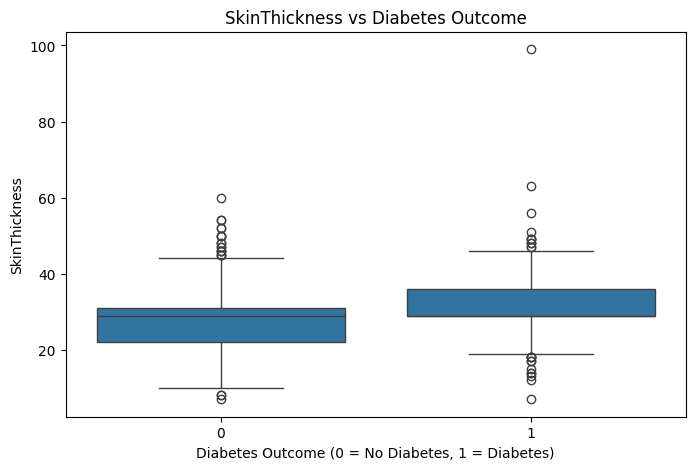

In [19]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Outcome', y='SkinThickness', data=df)

plt.title('SkinThickness vs Diabetes Outcome')
plt.xlabel('Diabetes Outcome (0 = No Diabetes, 1 = Diabetes)')
plt.ylabel('SkinThickness')

plt.show()

The boxplot shows that diabetic patients generally have slightly higher skin thickness measurements compared to non-diabetic patients.
However, there is substantial overlap between the two groups, suggesting that SkinThickness alone is not a strong predictor of diabetes outcome.
Several outliers are present in both groups, indicating variability and potential data quality concerns.

In [25]:
# check if these columns still have 0 values after cleaning
(df[['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']] == 0).sum()

Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64

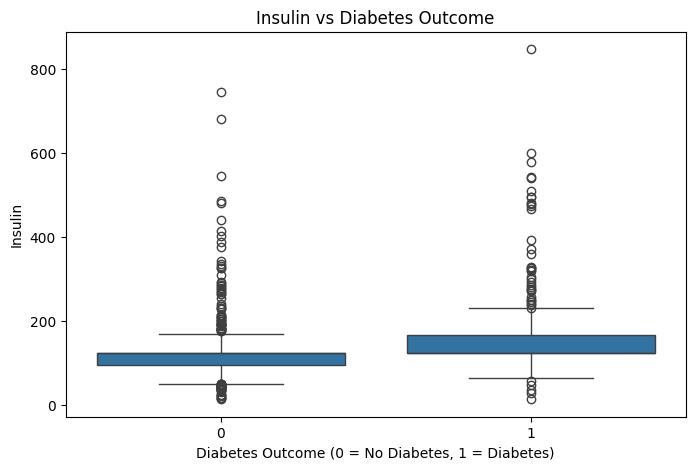

In [20]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Outcome', y='Insulin', data=df)

plt.title('Insulin vs Diabetes Outcome')
plt.xlabel('Diabetes Outcome (0 = No Diabetes, 1 = Diabetes)')
plt.ylabel('Insulin')

plt.show()

The boxplot shows that diabetic patients generally tend to have higher insulin levels compared to non-diabetic patients.
However, the Insulin variable displays substantial variability and many extreme outliers in both groups. There is also considerable overlap between diabetic and non-diabetic patients.
This suggests that while insulin may have some relationship with diabetes outcome, the feature is noisy and may require additional preprocessing.

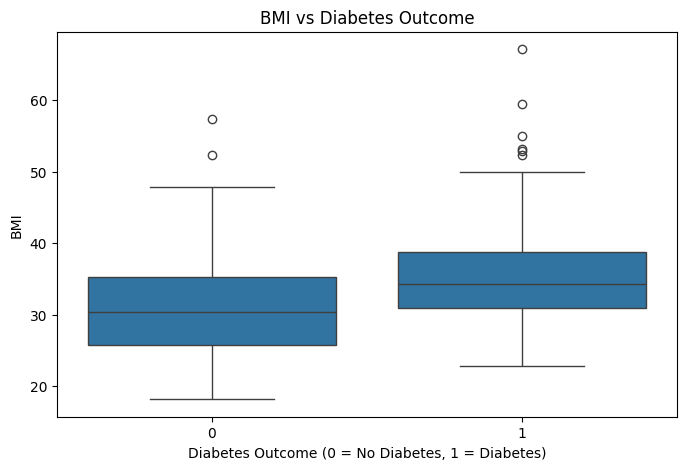

In [26]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Outcome', y='BMI', data=df)

plt.title('BMI vs Diabetes Outcome')
plt.xlabel('Diabetes Outcome (0 = No Diabetes, 1 = Diabetes)')
plt.ylabel('BMI')

plt.show()

The boxplot shows that diabetic patients generally have higher BMI values compared to non-diabetic patients.
The diabetic group has a higher median BMI and the distribution is shifted upward overall, suggesting that BMI may be an important predictor of diabetes outcome.
Although there is overlap between the groups, the relationship appears stronger than some other variables such as BloodPressure and SkinThickness.

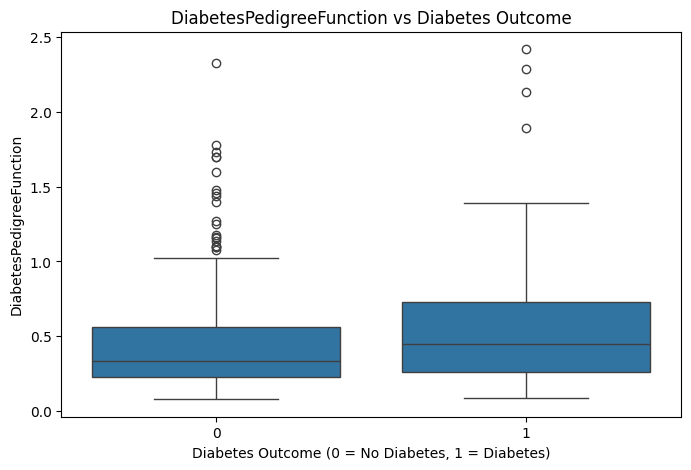

In [27]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Outcome', y='DiabetesPedigreeFunction', data=df)

plt.title('DiabetesPedigreeFunction vs Diabetes Outcome')
plt.xlabel('Diabetes Outcome (0 = No Diabetes, 1 = Diabetes)')
plt.ylabel('DiabetesPedigreeFunction')

plt.show()

The boxplot shows that individuals with diabetes generally have higher DiabetesPedigreeFunction values compared to individuals without diabetes. The diabetic group also exhibits greater variability and several high-value outliers, suggesting that hereditary or genetic factors may play a role in diabetes risk.

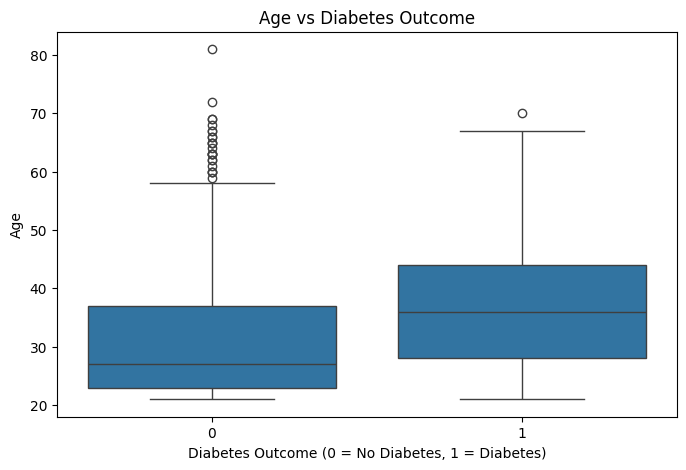

In [29]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Outcome', y='Age', data=df)

plt.title('Age vs Diabetes Outcome')
plt.xlabel('Diabetes Outcome (0 = No Diabetes, 1 = Diabetes)')
plt.ylabel('Age')

plt.show()

The boxplot indicates that individuals with diabetes tend to be older than individuals without diabetes. The median age is higher for the diabetic group, and the distribution of ages is more spread out. Although there is overlap between the two groups, age appears to have a positive relationship with diabetes outcome.

| Feature                  | Relationship Strength |
| ------------------------ | --------------------- |
| Glucose                  | Very Strong           |
| BMI                      | Strong                |
| Age                      | Moderate              |
| Pregnancies              | Moderate              |
| Insulin                  | Moderate (messy data) |
| DiabetesPedigreeFunction | Weak–Moderate         |
| SkinThickness            | Weak                  |
| BloodPressure            | Weak                  |


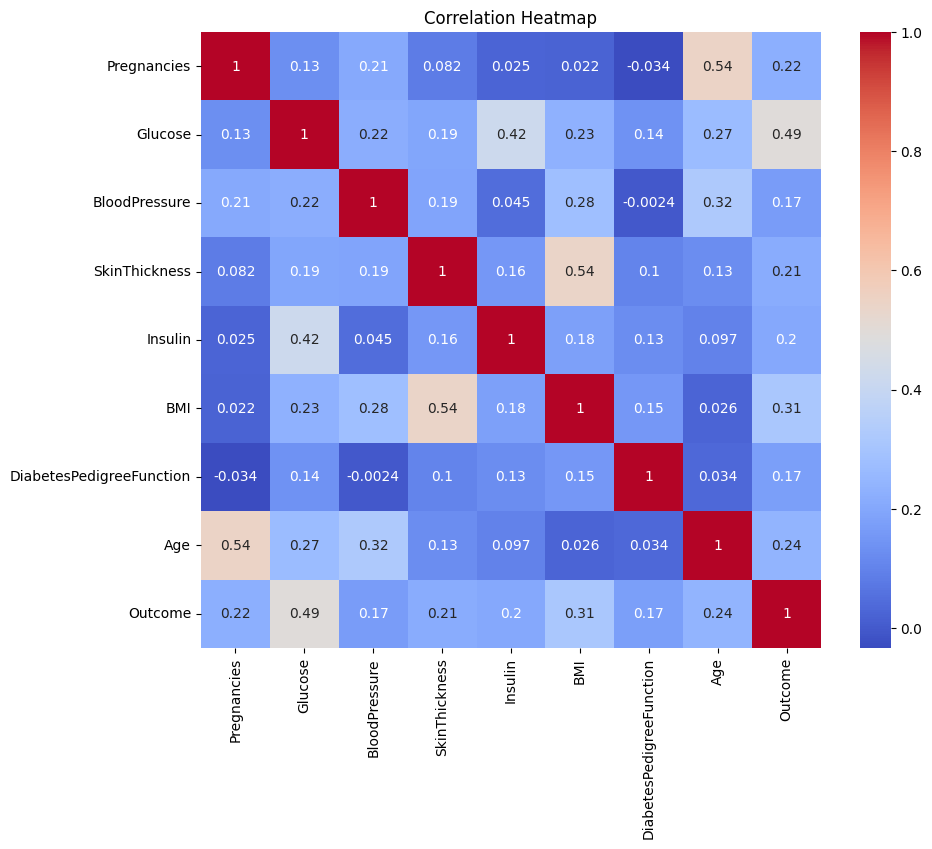

In [30]:
# which variables correlate most with Outcome
# which features correlate with each other
# possible multicollinearity patterns

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

The correlation heatmap shows that Glucose has the strongest positive correlation with diabetes outcome (0.49), followed by BMI (0.31) and Age (0.24). Other features such as Pregnancies, SkinThickness, Insulin, BloodPressure, and DiabetesPedigreeFunction show weaker positive correlations with the target variable. Additionally, several predictor variables are moderately correlated with one another, including BMI and SkinThickness (0.54), and Age and Pregnancies (0.54).

In [32]:
df['Outcome'].value_counts(normalize=True)

Outcome
0    0.651042
1    0.348958
Name: proportion, dtype: float64

The target variable Outcome is moderately imbalanced. About 65% of the observations are non-diabetic, while about 35% are diabetic. This imbalance is not extreme, but it should be considered during modeling because accuracy alone may be misleading. Metrics such as precision, recall, F1-score, ROC-AUC, and confusion matrix should be used.

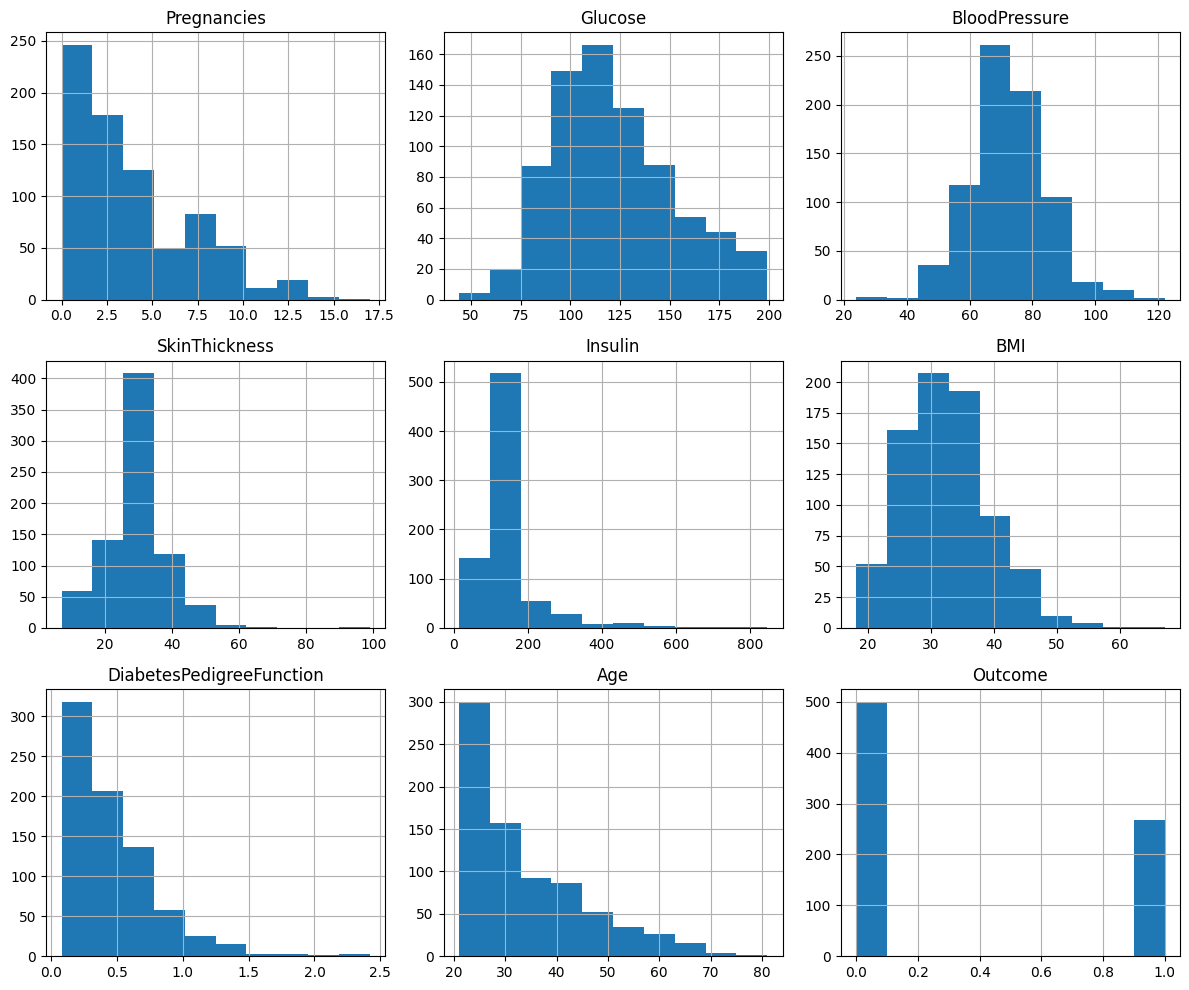

In [33]:
# X-axis = the feature values
# Y-axis = how many rows/patients have those values (frequency/count)

df.hist(figsize=(12,10))
plt.tight_layout()
plt.show()

The histograms show that several features, such as Insulin, DiabetesPedigreeFunction, and Age, are positively skewed. BloodPressure and BMI appear closer to a normal distribution. Insulin contains noticeable extreme values, suggesting the presence of outliers. The Outcome variable confirms a moderate class imbalance between diabetic and non-diabetic cases.

# Key EDA Findings
The target variable Outcome is moderately imbalanced, with approximately 65% non-diabetic cases and 35% diabetic cases.
Several medical variables originally contained invalid zero values (Glucose, BloodPressure, SkinThickness, Insulin, and BMI). These values were treated as missing data and replaced using median imputation.
Glucose shows the strongest positive relationship with diabetes outcome, suggesting it may be one of the most important predictors in the dataset.
BMI and Age also show moderate positive relationships with diabetes, indicating that higher BMI and older age may be associated with increased diabetes risk.
Most variables such as Insulin, DiabetesPedigreeFunction, and Age are positively skewed, meaning their distributions contain longer right tails.
Insulin contains significant outliers and extreme values, which may influence certain machine learning models.
BloodPressure and BMI appear closer to a normal distribution compared to the other variables.
Correlation analysis suggests that multicollinearity between independent variables is not severe, since no feature pairs show extremely high correlations.
Histograms and boxplots indicate noticeable differences between diabetic and non-diabetic groups for features such as Glucose, BMI, and Age.
The dataset appears suitable for predictive modeling after preprocessing steps such as scaling and train-test splitting.

# Implications for Preprocessing
Several variables such as Insulin and DiabetesPedigreeFunction are positively skewed and may benefit from scaling or transformation.
Significant outliers are present in features such as Insulin, which may impact certain machine learning models.
Features are measured on different scales, so feature scaling or standardization may improve model performance.
The target variable shows moderate class imbalance, therefore evaluation metrics beyond accuracy (such as precision, recall, F1-score, and ROC-AUC) should be considered during modeling.
The dataset is now cleaned and suitable for train-test splitting and machine learning preprocessing.

In [35]:
df.to_csv('../Data/cleaned_diabetes.csv', index=False)